<a href="https://colab.research.google.com/github/Ganika-R/24ADI003-EXP3/blob/main/24BAD025_DL_EXP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GANIKA R - 24BAD025


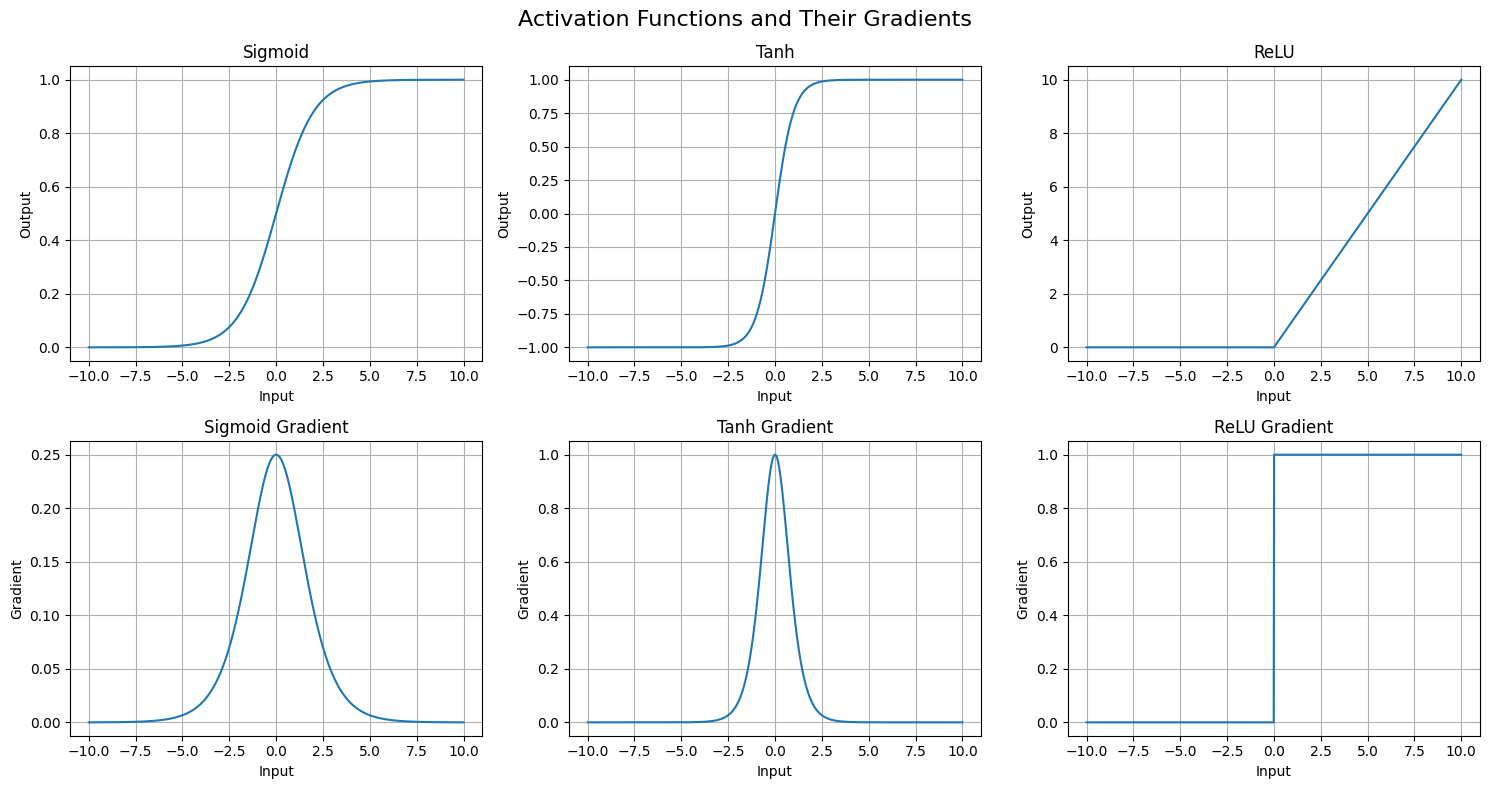


ACTIVATION FUNCTION COMPARISON
----------------------------------------------------------------------
Sigmoid : Output = 0 to 1 | Saturation = High | Gradient can vanish
Tanh    : Output = -1 to 1 | Saturation = High | Gradient can vanish
ReLU    : Output = 0 to infinity | Saturation = Low for positive inputs
ReLU is computationally efficient and widely used in hidden layers.


In [1]:
# TASK A: VISUALIZATION OF ACTIVATION FUNCTIONS
print("GANIKA R - 24BAD025")
import numpy as np
import matplotlib.pyplot as plt

# Input values
x = np.linspace(-10, 10, 1000)

# Activation functions
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)

# Gradients
sigmoid_grad = sigmoid * (1 - sigmoid)
tanh_grad = 1 - tanh**2
relu_grad = np.where(x > 0, 1, 0)

# Create plots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Activation functions
axes[0, 0].plot(x, sigmoid)
axes[0, 0].set_title("Sigmoid")
axes[0, 0].set_xlabel("Input")
axes[0, 0].set_ylabel("Output")
axes[0, 0].grid(True)

axes[0, 1].plot(x, tanh)
axes[0, 1].set_title("Tanh")
axes[0, 1].set_xlabel("Input")
axes[0, 1].set_ylabel("Output")
axes[0, 1].grid(True)

axes[0, 2].plot(x, relu)
axes[0, 2].set_title("ReLU")
axes[0, 2].set_xlabel("Input")
axes[0, 2].set_ylabel("Output")
axes[0, 2].grid(True)

# Gradients
axes[1, 0].plot(x, sigmoid_grad)
axes[1, 0].set_title("Sigmoid Gradient")
axes[1, 0].set_xlabel("Input")
axes[1, 0].set_ylabel("Gradient")
axes[1, 0].grid(True)

axes[1, 1].plot(x, tanh_grad)
axes[1, 1].set_title("Tanh Gradient")
axes[1, 1].set_xlabel("Input")
axes[1, 1].set_ylabel("Gradient")
axes[1, 1].grid(True)

axes[1, 2].plot(x, relu_grad)
axes[1, 2].set_title("ReLU Gradient")
axes[1, 2].set_xlabel("Input")
axes[1, 2].set_ylabel("Gradient")
axes[1, 2].grid(True)

plt.suptitle("Activation Functions and Their Gradients", fontsize=16)
plt.tight_layout()
plt.show()

# Comparison
print("\nACTIVATION FUNCTION COMPARISON")
print("-" * 70)
print("Sigmoid : Output = 0 to 1 | Saturation = High | Gradient can vanish")
print("Tanh    : Output = -1 to 1 | Saturation = High | Gradient can vanish")
print("ReLU    : Output = 0 to infinity | Saturation = Low for positive inputs")
print("ReLU is computationally efficient and widely used in hidden layers.")

GANIKA R - 24BAD025
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Training ANN using SIGMOID activation
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8027 - loss: 0.8685 - val_accuracy: 0.9132 - val_loss: 0.3491
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9183 - loss: 0.3010 - val_accuracy: 0.9350 - val_loss: 0.2393
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9354 - loss: 0.2262 - val_accuracy: 0.9452 - val_loss: 0.1991
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9473 - loss: 0.1831 - val_accuracy: 0.9517 - val_loss: 0.1716
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9561 - loss: 0.1528 - val_accuracy: 0.9548 - val_loss: 0.1551
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9629 - loss: 0.1294 - val_accuracy: 0.9609 - val_loss: 0.1347
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9686 - loss: 0.1113 - val_accuracy: 0.9655 - val_loss: 0

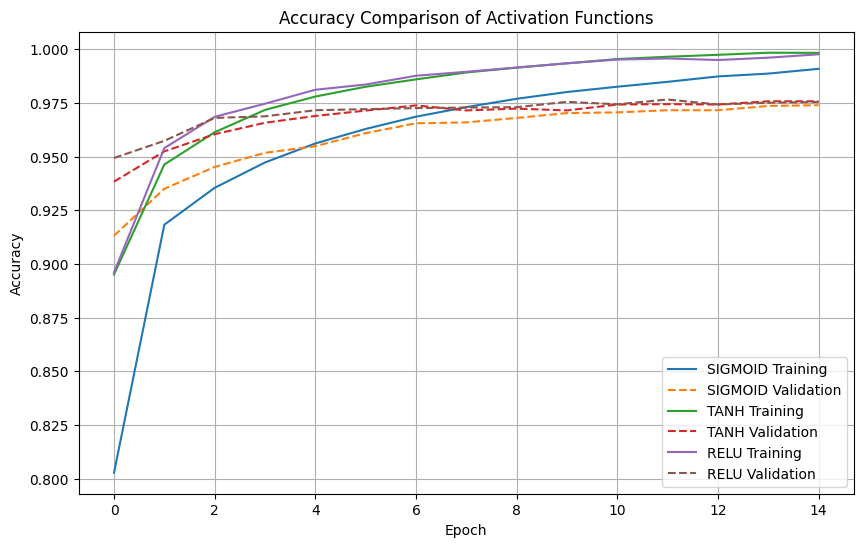

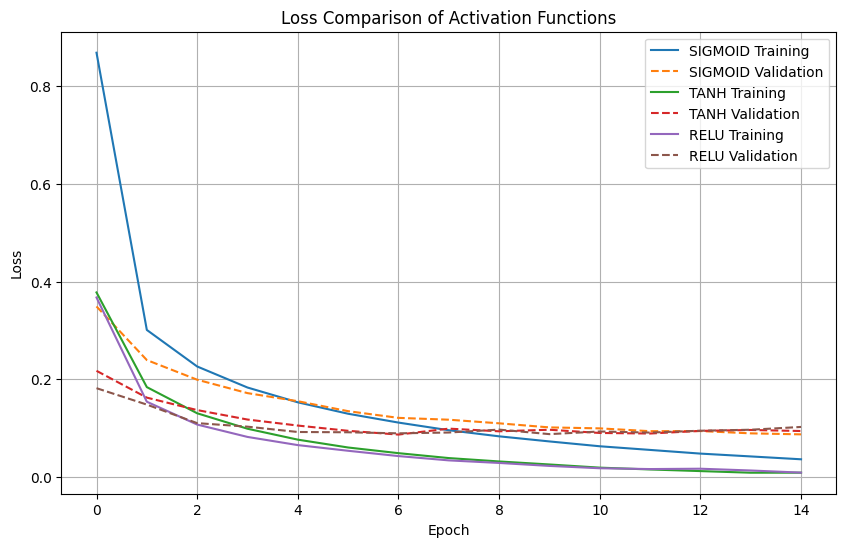



FINAL PERFORMANCE COMPARISON
Activation  Train Acc      Val Acc        Train Loss     Val Loss       Best Epoch
------------------------------------------------------------------------------------------
sigmoid     99.09          97.39          0.0362         0.0872         15        
tanh        99.83          97.58          0.0087         0.0940         14        
relu        99.76          97.54          0.0089         0.1024         12        

Best Performing Activation Function: TANH
It achieved the highest validation accuracy among the three activation functions.


In [2]:
# TASK B: PERFORMANCE COMPARISON OF ACTIVATION FUNCTIONS
print("GANIKA R - 24BAD025")
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

def create_model(activation):

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(784,)),
        tf.keras.layers.Dense(128, activation=activation),
        tf.keras.layers.Dense(64, activation=activation),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

activations = ["sigmoid", "tanh", "relu"]

histories = {}
results = {}

EPOCHS = 15

for activation in activations:

    print("\n" + "=" * 60)
    print("Training ANN using", activation.upper(), "activation")
    print("=" * 60)

    model = create_model(activation)

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=EPOCHS,
        batch_size=128,
        verbose=1
    )

    histories[activation] = history

    results[activation] = {
        "Training Accuracy": history.history["accuracy"][-1],
        "Validation Accuracy": history.history["val_accuracy"][-1],
        "Training Loss": history.history["loss"][-1],
        "Validation Loss": history.history["val_loss"][-1],
        "Best Epoch": np.argmax(history.history["val_accuracy"]) + 1
    }

plt.figure(figsize=(10, 6))

for activation in activations:
    plt.plot(
        histories[activation].history["accuracy"],
        label=activation.upper() + " Training"
    )
    plt.plot(
        histories[activation].history["val_accuracy"],
        linestyle="--",
        label=activation.upper() + " Validation"
    )

plt.title("Accuracy Comparison of Activation Functions")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

for activation in activations:
    plt.plot(
        histories[activation].history["loss"],
        label=activation.upper() + " Training"
    )
    plt.plot(
        histories[activation].history["val_loss"],
        linestyle="--",
        label=activation.upper() + " Validation"
    )

plt.title("Loss Comparison of Activation Functions")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

print("\n\nFINAL PERFORMANCE COMPARISON")
print("=" * 90)

print(
    f"{'Activation':<12}"
    f"{'Train Acc':<15}"
    f"{'Val Acc':<15}"
    f"{'Train Loss':<15}"
    f"{'Val Loss':<15}"
    f"{'Best Epoch':<10}"
)

print("-" * 90)

for activation in activations:

    r = results[activation]

    print(
        f"{activation:<12}"
        f"{r['Training Accuracy']*100:<15.2f}"
        f"{r['Validation Accuracy']*100:<15.2f}"
        f"{r['Training Loss']:<15.4f}"
        f"{r['Validation Loss']:<15.4f}"
        f"{r['Best Epoch']:<10}"
    )

best_activation = max(
    results,
    key=lambda x: results[x]["Validation Accuracy"]
)

print("\nBest Performing Activation Function:",
      best_activation.upper())

print(
    "It achieved the highest validation accuracy among "
    "the three activation functions."
)

GANIKA R - 24BAD025

Training using SGD
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6337 - loss: 1.4516 - val_accuracy: 0.8407 - val_loss: 0.7522
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8556 - loss: 0.5987 - val_accuracy: 0.8851 - val_loss: 0.4523
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8830 - loss: 0.4364 - val_accuracy: 0.8986 - val_loss: 0.3734
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8954 - loss: 0.3769 - val_accuracy: 0.9059 - val_loss: 0.3353
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9036 - loss: 0.3438 - val_accuracy: 0.9128 - val_loss: 0.3109
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9084 - loss: 0.3214 - val_accuracy: 0.9178 - val_loss: 0.2941
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9145 - loss: 0.3039 - val_accuracy: 0.9208 - val_loss: 0.2805
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 

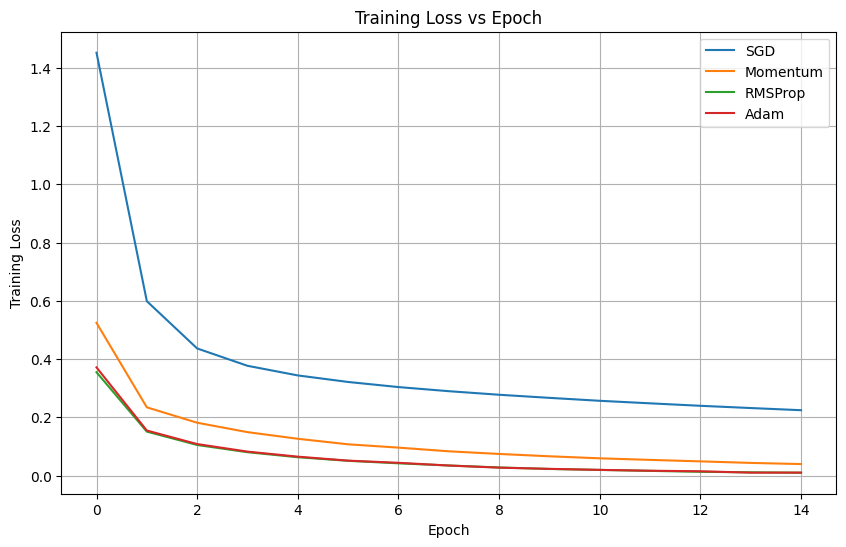

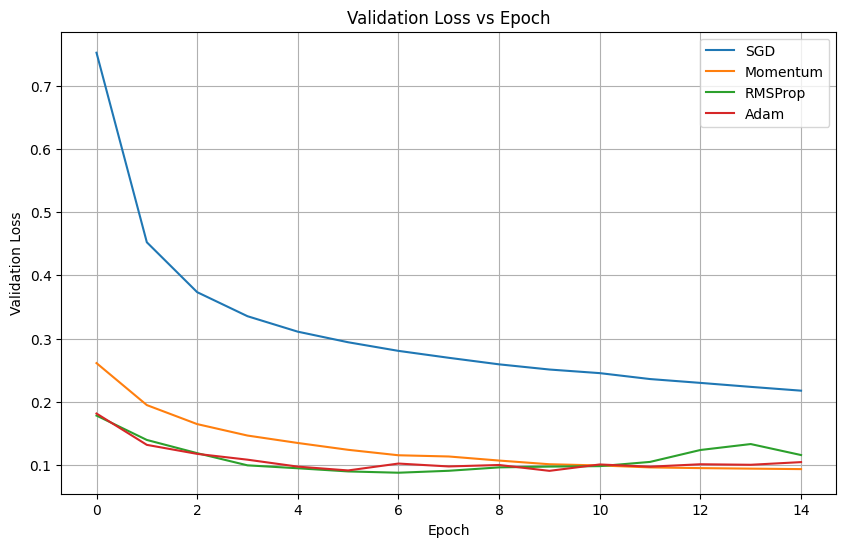

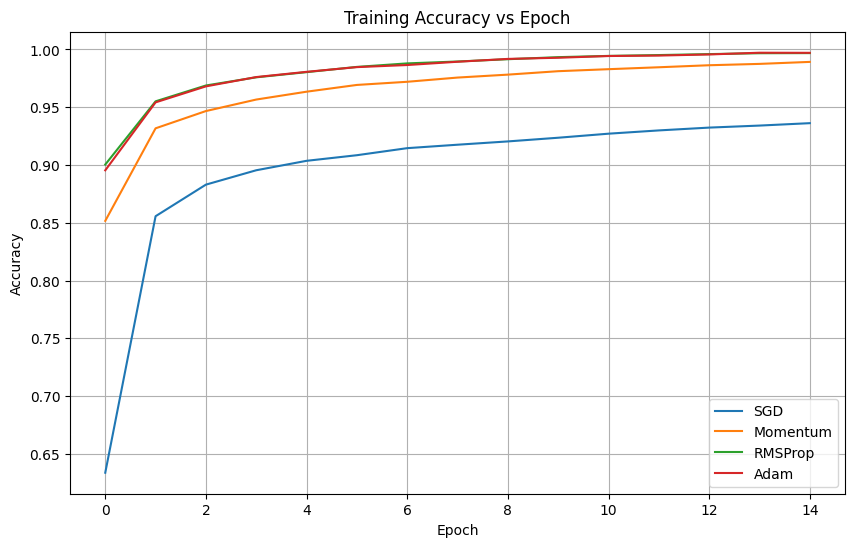

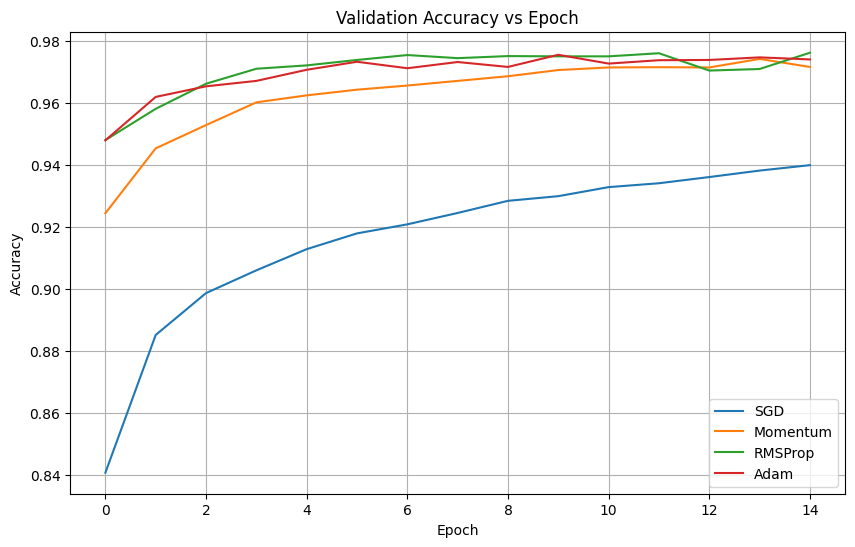



FINAL OPTIMIZER COMPARISON
Optimizer   Train Loss     Val Loss       Train Acc      Val Acc        Best Epoch
----------------------------------------------------------------------------------------------------
SGD         0.2245         0.2175         93.62          93.98          15        
Momentum    0.0396         0.0934         98.92          97.15          14        
RMSProp     0.0099         0.1157         99.68          97.61          15        
Adam        0.0103         0.1045         99.70          97.39          10        

Best Performing Optimizer: RMSProp
The best optimizer is selected based on the highest validation accuracy.


In [4]:
# TASK C: COMPARISON OF OPTIMIZATION ALGORITHMS
print("GANIKA R - 24BAD025")
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

def create_model(optimizer):

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(784,)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

optimizers = {
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.01),

    "Momentum": tf.keras.optimizers.SGD(
        learning_rate=0.01,
        momentum=0.9
    ),

    "RMSProp": tf.keras.optimizers.RMSprop(
        learning_rate=0.001
    ),

    "Adam": tf.keras.optimizers.Adam(
        learning_rate=0.001
    )
}

histories = {}
results = {}

EPOCHS = 15

for name, optimizer in optimizers.items():

    print("\n" + "=" * 60)
    print("Training using", name)
    print("=" * 60)

    model = create_model(optimizer)

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=EPOCHS,
        batch_size=128,
        verbose=1
    )

    histories[name] = history

    results[name] = {
        "Training Loss": history.history["loss"][-1],
        "Validation Loss": history.history["val_loss"][-1],
        "Training Accuracy": history.history["accuracy"][-1],
        "Validation Accuracy": history.history["val_accuracy"][-1],
        "Best Epoch": np.argmax(history.history["val_accuracy"]) + 1
    }

plt.figure(figsize=(10, 6))

for name in histories:

    plt.plot(
        histories[name].history["loss"],
        label=name
    )

plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

for name in histories:

    plt.plot(
        histories[name].history["val_loss"],
        label=name
    )

plt.title("Validation Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

for name in histories:

    plt.plot(
        histories[name].history["accuracy"],
        label=name
    )

plt.title("Training Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

for name in histories:

    plt.plot(
        histories[name].history["val_accuracy"],
        label=name
    )

plt.title("Validation Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

print("\n\nFINAL OPTIMIZER COMPARISON")
print("=" * 100)

print(
    f"{'Optimizer':<12}"
    f"{'Train Loss':<15}"
    f"{'Val Loss':<15}"
    f"{'Train Acc':<15}"
    f"{'Val Acc':<15}"
    f"{'Best Epoch':<10}"
)

print("-" * 100)

for name in optimizers:

    r = results[name]

    print(
        f"{name:<12}"
        f"{r['Training Loss']:<15.4f}"
        f"{r['Validation Loss']:<15.4f}"
        f"{r['Training Accuracy']*100:<15.2f}"
        f"{r['Validation Accuracy']*100:<15.2f}"
        f"{r['Best Epoch']:<10}"
    )

best_optimizer = max(
    results,
    key=lambda x: results[x]["Validation Accuracy"]
)

print("\nBest Performing Optimizer:",
      best_optimizer)

print(
    "The best optimizer is selected based on the highest "
    "validation accuracy."
)